In [48]:
#Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

In [49]:
#Load Dataset
df = pd.read_csv("C:/Users/s/OneDrive/Desktop/studentss.csv")
print(df.head())
print(df.tail())

       student_name  hours_studied  attendance  previous_grades  \
0       ali ballout           11.0        57.0             41.0   
1      daniel msadi            4.0        64.0             48.0   
2      ahmad alayli            NaN         NaN             45.0   
3  mohamad hamadani            1.0        51.0             45.0   
4    abo diz lnemer            4.0        82.0             78.0   

   sleeping_hours  job  project_score final_result  
0             6.0  0.0           65.0         Fail  
1             5.0  1.0           75.0         Fail  
2             NaN  NaN           57.0         Fail  
3             9.0  1.0           96.0         Fail  
4             4.0  1.0           48.0         Fail  
         student_name  hours_studied  attendance  previous_grades  \
205   Abdullah Hassan            7.0        85.0             41.0   
206  Mahmoud Abdullah            8.0        52.0             78.0   
207      Yousef Ahmad            8.0        66.0             61.0   
208

In [50]:
# Missing values

print("\nMissing values before filling:")
print(df.isnull().sum())




Missing values before filling:
student_name       0
hours_studied      4
attendance         1
previous_grades    4
sleeping_hours     3
job                3
project_score      5
final_result       0
dtype: int64


In [51]:
# Convert target to numerical
le = LabelEncoder()
df["final_result"] = le.fit_transform(df["final_result"])

In [52]:
# Numerical columns
numeric_cols = [
    "hours_studied",
    "attendance",
    "previous_grades",
    "sleeping_hours",
    "job",
    "project_score"
]

In [53]:
# Fill missing values
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
student_name       0
hours_studied      0
attendance         0
previous_grades    0
sleeping_hours     0
job                0
project_score      0
final_result       0
dtype: int64


In [54]:
# Features and target
X = df.drop(columns=["student_name", "final_result"])
y = df["final_result"]

In [55]:
# Cross-Validation (Random Forest)
print("\nCross-Validation (5-Fold)")

rf_cv = RandomForestClassifier()
cv_scores = cross_val_score(rf_cv, X, y, cv=5)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())


Cross-Validation (5-Fold)
CV Scores: [0.88095238 0.85714286 0.85714286 0.88095238 0.78571429]
Mean CV Accuracy: 0.8523809523809524
Standard Deviation: 0.034992710611188256


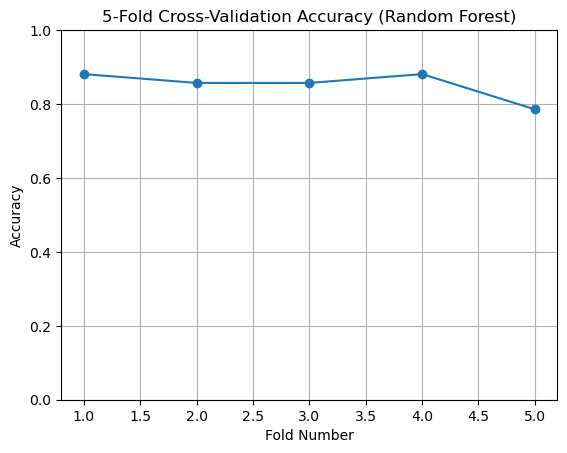

In [56]:
#Cross-Validation Graph 
plt.figure()
plt.plot(range(1, 6), cv_scores, marker='o')
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy (Random Forest)")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

In [ ]:
# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)


In [58]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("\nLogistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))



Logistic Regression
Accuracy: 0.7380952380952381
              precision    recall  f1-score   support

           0       0.83      0.74      0.78        27
           1       0.61      0.73      0.67        15

    accuracy                           0.74        42
   macro avg       0.72      0.74      0.73        42
weighted avg       0.75      0.74      0.74        42



In [59]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))


Decision Tree
Accuracy: 0.8095238095238095
              precision    recall  f1-score   support

           0       0.88      0.81      0.85        27
           1       0.71      0.80      0.75        15

    accuracy                           0.81        42
   macro avg       0.79      0.81      0.80        42
weighted avg       0.82      0.81      0.81        42



In [60]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest
Accuracy: 0.8571428571428571
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        27
           1       0.80      0.80      0.80        15

    accuracy                           0.86        42
   macro avg       0.84      0.84      0.84        42
weighted avg       0.86      0.86      0.86        42



Accuracy score: 78.57%


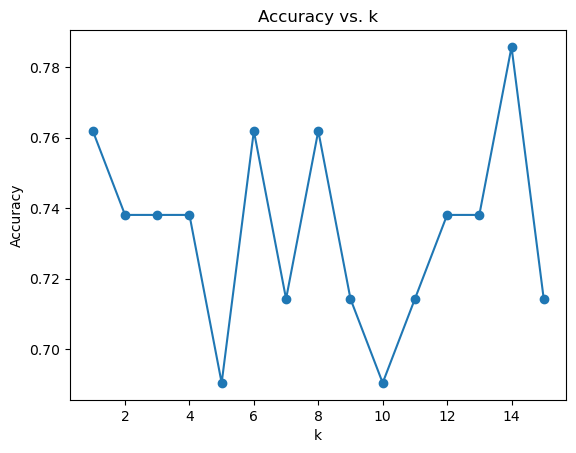

In [ ]:
# K-Nearest Neighbors 
max_k = min(15, len(X_train))

best_accuracy = 0
best_k = 0
accuracy_values = []
k_values = []

for k in range(1, max_k + 1):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    accuracy_values.append(accuracy)
    k_values.append(k)
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_k = k

# Train KNN again using the best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy score: {}%'.format(round(accuracy * 100, 2)))

# Plot Accuracy vs k
plt.plot(k_values, accuracy_values, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. k')
plt.show()

In [71]:
# Model comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "knn"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, y_pred)
    ]
})

print("\nModel Comparison:")
print(comparison)



Model Comparison:
                 Model  Accuracy
0  Logistic Regression  0.738095
1        Decision Tree  0.809524
2        Random Forest  0.857143
3                  knn  0.785714


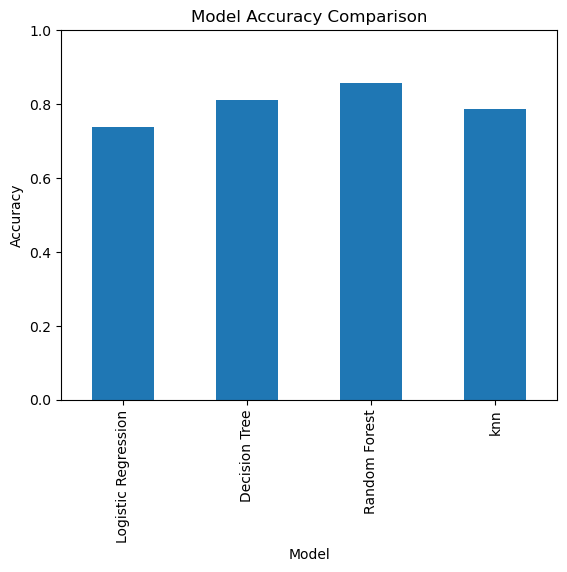

In [72]:
# Plot model comparison
comparison.plot(x="Model", y="Accuracy", kind="bar", legend=False)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

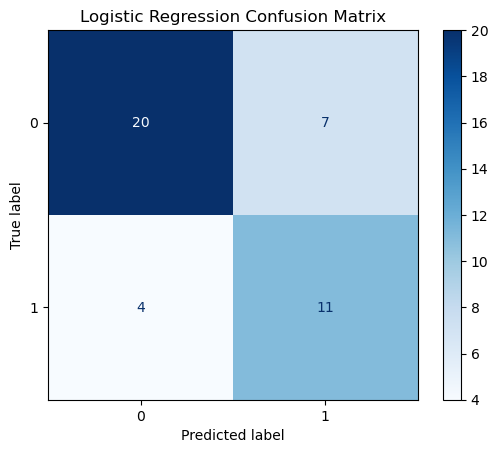

In [73]:
# Confusion Matrix - Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    cmap="Blues"
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

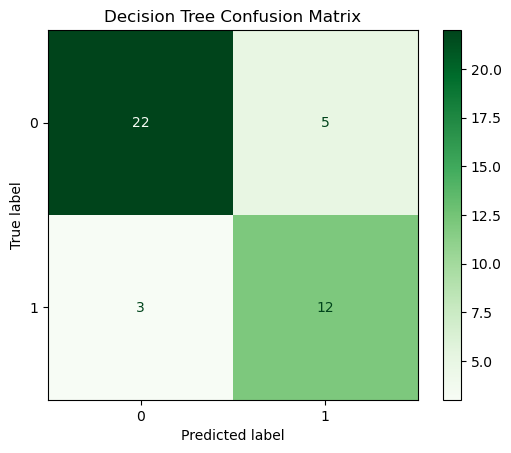

In [74]:
# Confusion Matrix - Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Greens"
)
plt.title("Decision Tree Confusion Matrix")
plt.show()

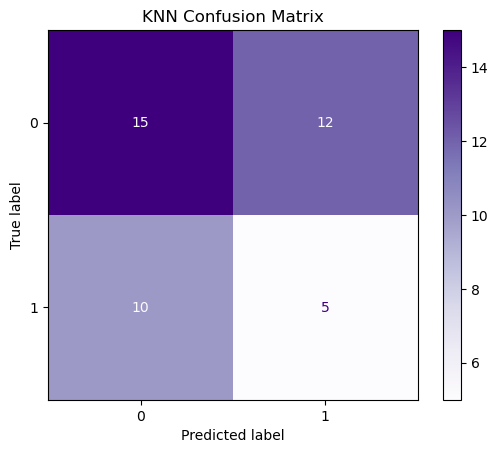

In [75]:
# Confusion Matrix - KNN
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    cmap="Purples"
)
plt.title("KNN Confusion Matrix")
plt.show()


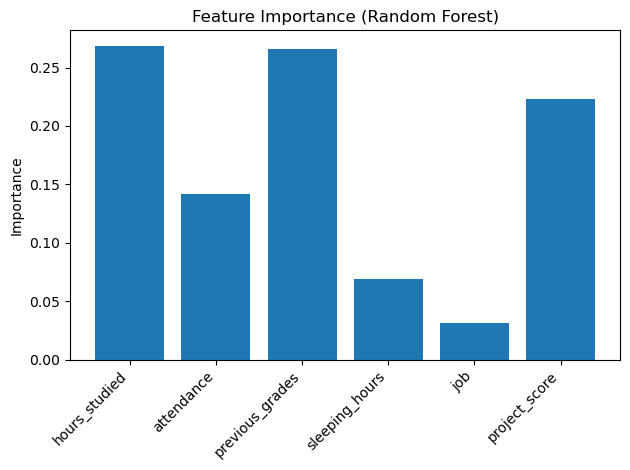

In [76]:
# Feature Importance - Random Forest
plt.bar(X.columns, rf.feature_importances_)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

In [79]:
pass_count = np.sum(y_pred == 1)
fail_count = np.sum(y_pred == 0)
total = len(y_pred)

In [80]:
pass_percentage = (pass_count / total) * 100
fail_percentage = (fail_count / total) * 100

In [81]:
print(f"Predicted Pass Percentage (Random Forest): {pass_percentage:.2f}%")
print(f"Predicted Fail Percentage (Random Forest): {fail_percentage:.2f}%")

Predicted Pass Percentage (Random Forest): 38.10%
Predicted Fail Percentage (Random Forest): 61.90%


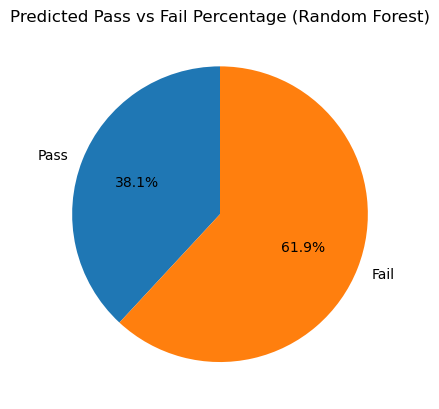

In [83]:
plt.figure()
plt.pie(
    [pass_percentage, fail_percentage],
    labels=["Pass", "Fail"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Predicted Pass vs Fail Percentage (Random Forest)")
plt.show()